# 01 - Load Data, Check for Leakage, EDA

Dataset: **PhiUSIIL Phishing URL Dataset** (UCI id 967).
235,795 URLs, 54 features. Target is `label`: 1 = legitimate,
0 = phishing.

This dataset is known to be "too easy" if you throw every column at a
model (see `docs/phiusiil_phishing_assessment.md`), so before any
modeling we check for data leakage. In this notebook we:

1. load the data (downloaded once with `code/fetch_data.py`)
2. look at class balance and duplicates
3. check the leaky / suspicious columns (`URLSimilarityIndex`,
   too-perfect yes/no features, repeated domains, `TLD`)
4. save the list of safe feature columns for notebooks 02 and 03

The overall plan is in `docs/project_plan.md`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler

DATA_PATH = Path("../data/phiusiil.csv")

In [2]:
df = pd.read_csv(DATA_PATH)
y = df["label"]

print(f"shape: {df.shape}")
print(f"missing values: {df.isna().sum().sum()}")
print()
print("column types:")
print(df.dtypes.value_counts())
df.head(3)

shape: (235795, 55)
missing values: 0

column types:
int64      41
float64    10
str         4
Name: count, dtype: int64


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1


No missing values at all, which matches the UCI description. The 4
string columns are `URL`, `Domain`, `TLD` and `Title`.

## Class balance

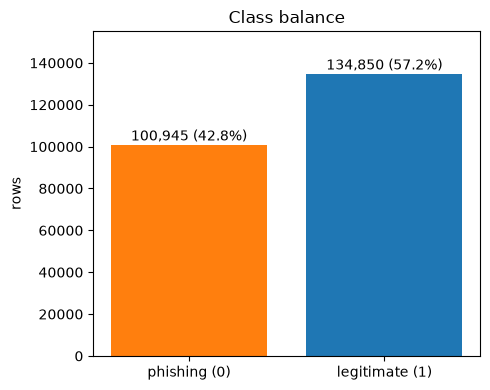

In [3]:
counts = y.value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(
    ["phishing (0)", "legitimate (1)"],
    counts.values,
    color=["tab:orange", "tab:blue"],
)
for i, c in enumerate(counts.values):
    plt.text(i, c + 2000, f"{c:,} ({c / len(df):.1%})", ha="center")
plt.ylabel("rows")
plt.title("Class balance")
plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

About 57% legitimate / 43% phishing. The proposal feedback assumed a
heavily imbalanced dataset, but this is only a mild imbalance. So we
don't need aggressive resampling. Plan: use class weights in the models
and try SMOTE only as a comparison experiment (see the project plan).

## Duplicate rows and duplicate URLs

In [4]:
dup_url_extra = int(df["URL"].duplicated().sum())
dups = df[df["URL"].duplicated(keep=False)]
conflicts = dups.groupby("URL")["label"].nunique()

print(f"exact duplicate rows: {df.duplicated().sum()}")
print(f"repeated URLs (extra rows): {dup_url_extra}")
print(f"repeated URLs with conflicting labels: {(conflicts > 1).sum()}")

exact duplicate rows: 0
repeated URLs (extra rows): 425
repeated URLs with conflicting labels: 0


No fully duplicated rows, but 425 URLs appear more than once (always
with the same label). If the same URL lands in both train and test,
the model gets tested on something it literally saw during training.
Notebook 02 should drop duplicate URLs before splitting.

## Leakage check 1: `URLSimilarityIndex`

This column measures how similar a URL is to known legitimate URLs, so
it basically contains the answer.

In [5]:
print(df.groupby("label")["URLSimilarityIndex"].describe())

n_100 = ((df["URLSimilarityIndex"] == 100) & (y == 0)).sum()
print(f"\nphishing rows that also score exactly 100: {n_100}")

          count        mean        std         min         25%         50%  \
label                                                                        
0      100945.0   49.616973  22.572082    0.155574   32.120613   51.419332   
1      134850.0  100.000000   0.000000  100.000000  100.000000  100.000000   

              75%    max  
label                     
0       67.251462  100.0  
1      100.000000  100.0  

phishing rows that also score exactly 100: 786


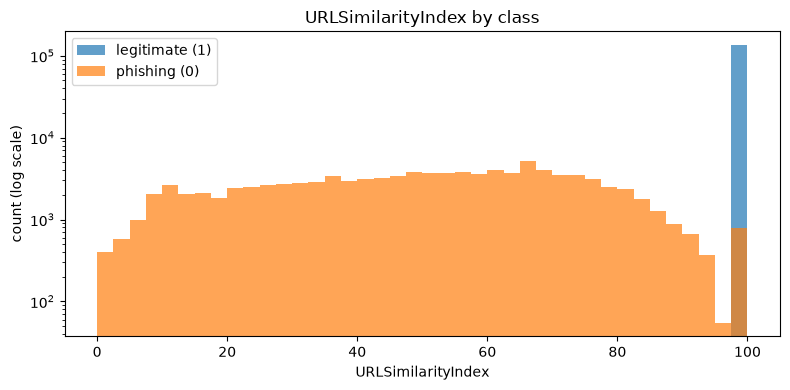

In [6]:
bins = np.linspace(0, 100, 41)

plt.figure(figsize=(8, 4))
plt.hist(
    df.loc[y == 1, "URLSimilarityIndex"],
    bins=bins,
    alpha=0.7,
    color="tab:blue",
    label="legitimate (1)",
)
plt.hist(
    df.loc[y == 0, "URLSimilarityIndex"],
    bins=bins,
    alpha=0.7,
    color="tab:orange",
    label="phishing (0)",
)
plt.yscale("log")
plt.xlabel("URLSimilarityIndex")
plt.ylabel("count (log scale)")
plt.title("URLSimilarityIndex by class")
plt.legend()
plt.tight_layout()
plt.show()

Every single legitimate URL scores exactly 100 (std = 0). That is
clearly leakage. It's not perfect in the other direction though: 786
phishing URLs also score 100, so the column alone can't reach 100%
accuracy. The log scale is needed because the legitimate spike at 100
(134,850 rows) would otherwise flatten the phishing distribution.

How much does this one column matter? Quick test with a plain logistic
regression: the leaky column alone vs. all the other numeric features.

In [7]:
def quick_logreg(X, y, groups=None):
    """Train a basic logistic regression, return test acc and F1."""
    if groups is None:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
    else:
        # keep all rows of the same group on one side of the split
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(gss.split(X, y, groups=groups))
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds), f1_score(y_test, preds)


numeric_cols = df.select_dtypes("number").columns
safe_cols = [
    c for c in numeric_cols if c not in ("URLSimilarityIndex", "label")
]

acc1, f11 = quick_logreg(df[["URLSimilarityIndex"]], y)
acc2, f12 = quick_logreg(df[safe_cols], y)

print(f"URLSimilarityIndex alone: acc={acc1:.4f}  f1={f11:.4f}")
print(f"all other numeric cols:   acc={acc2:.4f}  f1={f12:.4f}")

URLSimilarityIndex alone: acc=0.9960  f1=0.9965
all other numeric cols:   acc=0.9992  f1=0.9993


The leaky column alone gets 99.6%. But here is the surprise: dropping
it barely matters, because the remaining ~50 features together get
99.9%. So the dataset is almost trivially easy even without the leaky
column. That makes sense (features like `HasPasswordField` or
`LineOfCode` come from crawling the actual page), but it means our
tabular models solve an easy version of the problem. That is why the
plan also includes a model that only sees the raw URL string
(notebook 03) — that one is the honest "hard mode" result.

## Leakage check 2: too-perfect yes/no features

If one class almost always has a flag and the other almost never does,
that smells like an artifact of how the dataset was collected rather
than a real-world rule. Check the rate of every binary feature per
class.

In [8]:
binary_cols = [
    c for c in numeric_cols if c != "label" and set(df[c].unique()) <= {0, 1}
]

rates = df.groupby("label")[binary_cols].mean().T
rates.columns = ["phishing_rate", "legit_rate"]
rates["gap"] = (rates["legit_rate"] - rates["phishing_rate"]).abs()
rates = rates.sort_values("gap", ascending=False)

print(f"{len(binary_cols)} binary feature columns")
rates.head(10).round(3)

19 binary feature columns


,phishing_rate,legit_rate,gap
HasSocialNet,0.005,0.795,0.789
HasCopyrightInfo,0.057,0.808,0.751
HasDescription,0.044,0.737,0.692
HasSubmitButton,0.085,0.661,0.576
IsResponsive,0.317,0.854,0.537
IsHTTPS,0.492,1.000,0.508
HasHiddenFields,0.093,0.591,0.498
HasFavicon,0.088,0.567,0.479
Robots,0.066,0.417,0.351
HasTitle,0.678,0.999,0.321


The standout is `IsHTTPS`: **100% of legitimate URLs use HTTPS**, with
zero exceptions, while about half the phishing URLs do too. A rule
"no HTTPS = phishing" would never be wrong on this dataset, which is
not true of the real web — it's a side effect of where the legitimate
URLs were collected from. `HasSocialNet`, `HasCopyrightInfo` and
`HasDescription` have huge gaps too (real sites have footers and meta
tags, parked phishing pages usually don't).

Does the easiness depend on just these few giveaway flags? Drop the
top 6 (that includes `IsHTTPS`) and re-run the quick model.

In [9]:
giveaways = rates.index[:6].tolist()
print("dropping:", giveaways)

acc3, f13 = quick_logreg(df[[c for c in safe_cols if c not in giveaways]], y)
print(f"without giveaway flags: acc={acc3:.4f}  f1={f13:.4f}")

dropping: ['HasSocialNet', 'HasCopyrightInfo', 'HasDescription', 'HasSubmitButton', 'IsResponsive', 'IsHTTPS']


without giveaway flags: acc=0.9973  f1=0.9976


Accuracy barely moves. The easiness is spread across the whole feature
set, not hidden in a few columns, so there is no clean line where we
could keep "some" content features and get an honest problem. Decision:
keep these features for the tabular models (notebook 02), but call out
`IsHTTPS` and friends in the report as collection artifacts, and treat
the URL-only model in notebook 03 as the realistic difficulty level.

## Leakage check 3: repeated domains

`URL` and `Domain` are basically IDs, so they stay out of the feature
set either way. But if the same domain shows up in both train and test,
the model can memorize the domain instead of learning patterns. How
often do domains repeat?

In [10]:
domain_counts = df["Domain"].value_counts()
repeated = domain_counts[domain_counts > 1]

print(f"unique domains: {len(domain_counts):,} / {len(df):,} rows")
print(
    f"domains appearing more than once: {len(repeated):,} "
    f"({repeated.sum():,} rows, {repeated.sum() / len(df):.1%})"
)
domain_counts.head(10)

unique domains: 220,086 / 235,795 rows
domains appearing more than once: 5,526 (21,235 rows, 9.0%)


Domain
ipfs.io                         1197
docs.google.com                  526
mail.deliverylifesupport.com     370
cloudflare-ipfs.com              359
storageapi.fleek.co              318
gateway.pinata.cloud             275
gateway.ipfs.io                  249
ipfs.litnet.work                 223
cf-ipfs.com                      190
s3.amazonaws.com                 182
Name: count, dtype: int64

About 9% of rows share a domain with another row. Note the top of the
list: `ipfs.io`, `gateway.ipfs.io`, `cloudflare-ipfs.com` and
`cf-ipfs.com` are all gateways to the same IPFS service, so exact
string matching actually *under*-counts how related the rows are.
Being stricter would mean grouping by registered domain (e.g. with the
`tldextract` package), but we keep it simple here.

Does this repetition actually inflate the score? Compare a normal
random split against a split that keeps each domain on one side only.

In [11]:
acc4, f14 = quick_logreg(df[safe_cols], y, groups=df["Domain"])

print(f"normal random split:  acc={acc2:.4f}  f1={f12:.4f}")
print(f"domain-grouped split: acc={acc4:.4f}  f1={f14:.4f}")

normal random split:  acc=0.9992  f1=0.9993
domain-grouped split: acc=0.9995  f1=0.9996


Essentially no difference — the score was not inflated by repeated
domains, the dataset is just this easy. Still, the grouped split is the
safer choice and costs nothing, so notebook 02 uses
`GroupShuffleSplit` on `Domain` and reports both.

## The `TLD` column

In [12]:
print(f"unique TLDs: {df['TLD'].nunique()}")
print(df["TLD"].value_counts().head(10))

weird = df["TLD"].astype(str).str.fullmatch(r"\d+")
is_ip = df.loc[weird, "IsDomainIP"] == 1
print(f"\nrows where the 'TLD' is just a number: {weird.sum()}")
print(f"of those, IsDomainIP == 1: {is_ip.sum()}")
print(f"labels of those rows: {df.loc[weird, 'label'].unique()}")
df.loc[weird, ["Domain", "TLD", "label"]].head(3)

unique TLDs: 695
TLD
com    112554
org     18793
net      7097
app      6508
uk       6395
co       5422
io       4201
de       3996
ru       3875
au       2979
Name: count, dtype: int64

rows where the 'TLD' is just a number: 599
of those, IsDomainIP == 1: 599
labels of those rows: [0]


,Domain,TLD,label
125,198.98.58.123,123,0
401,43.134.167.94,94,0
1205,43.128.92.128,128,0


Two findings. First, 695 unique TLDs is too many to one-hot encode.
Second, 599 of them aren't TLDs at all: for URLs that use a raw IP
address, whoever built the dataset took the last number of the IP as
the "TLD" (e.g. domain `198.98.58.123` gets TLD `123`). All 599 of
those rows are phishing. `IsDomainIP` already captures this signal, so
it's a data-quality quirk to mention, not something to fix.

Instead of encoding `TLD` we plan to use `TLDLegitimateProb`, a
provided score for how trustworthy the TLD is. One worry: if UCI
computed that score *from this dataset's own labels*, it would be
target leakage just like `URLSimilarityIndex`. Quick check: compare it
against the share of legitimate rows per TLD in our data.

In [13]:
legit_share_per_tld = df.groupby("TLD")["label"].mean()
legit_share = df["TLD"].map(legit_share_per_tld)

corr = legit_share.corr(df["TLDLegitimateProb"])
print(f"corr with per-TLD legit share in this data: {corr:.3f}")

corr with per-TLD legit share in this data: 0.176


If the score had been computed from these labels the correlation would
be close to 1. At ~0.18 it clearly wasn't (it comes from some outside
source), so it's fine to keep as a feature.

## Which safe features correlate with the label?

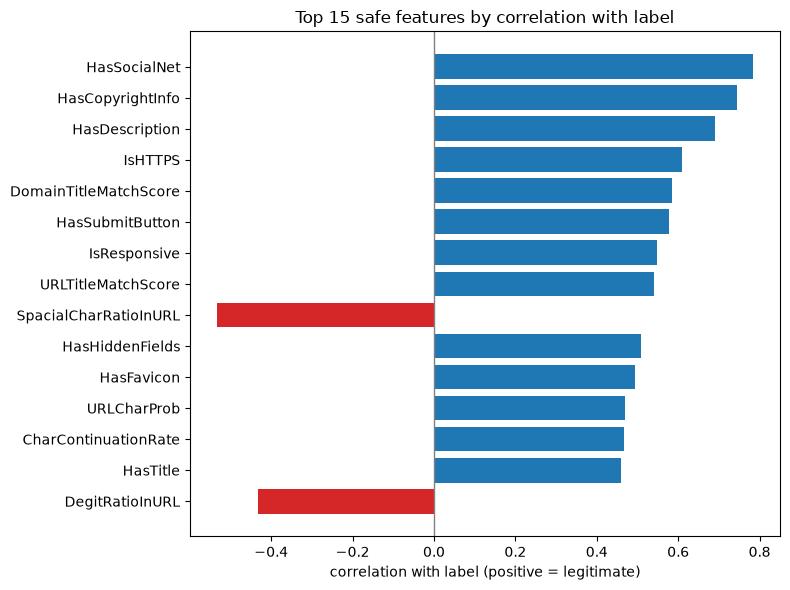

In [14]:
corrs = df[safe_cols].corrwith(y)
top15 = corrs.reindex(corrs.abs().sort_values().index).tail(15)
colors = ["tab:blue" if v > 0 else "tab:red" for v in top15]

plt.figure(figsize=(8, 6))
plt.barh(top15.index, top15.values, color=colors)
plt.axvline(0, color="gray", linewidth=1)
plt.xlabel("correlation with label (positive = legitimate)")
plt.title("Top 15 safe features by correlation with label")
plt.tight_layout()
plt.show()

The strongest safe features are mostly page-content ones
(`HasSocialNet`, `HasCopyrightInfo`, `IsHTTPS`, ...), matching the
leakage-check results above. One caveat: plain correlation understates
skewed count features like `LineOfCode` or `NoOfImage`, so we'll rely
on model-based feature importance in notebook 02 rather than this
chart for feature selection.

## Save the safe feature list for notebooks 02 and 03

So the other notebooks all use the same agreed feature set. (The
`FILENAME` id column mentioned in the assessment doc doesn't exist in
the `ucimlrepo` version, so there's nothing to drop there.)

In [15]:
LEAKY_COLS = ["URLSimilarityIndex", "URL", "Domain", "Title"]

clean_features = [
    c for c in df.columns if c not in LEAKY_COLS + ["label", "TLD"]
]

manifest = {
    "target": "label",
    "dropped_leaky": LEAKY_COLS,
    "dropped_identifier": [],
    "categorical_raw": ["TLD"],
    "drop_duplicate_urls": True,
    "split_group_column": "Domain",
    "clean_numeric_features": clean_features,
}

out_path = Path("../data/feature_columns.json")
out_path.write_text(json.dumps(manifest, indent=2))
print(f"saved {len(clean_features)} feature names to {out_path}")

saved 49 feature names to ../data/feature_columns.json


## Summary

- **Class balance is mild** (57/43), not severe. Class weights first,
  SMOTE only as a comparison.
- **`URLSimilarityIndex` is leaky** (every legitimate row = 100) and is
  dropped. But the other features still reach ~99.9%, so the dataset
  is easy with or without it — the URL-string-only model in notebook
  03 is our realistic-difficulty comparison.
- **`IsHTTPS` is a collection artifact** (100% of legitimate rows are
  HTTPS). We keep it but flag it in the report; dropping the top
  giveaway flags barely changes accuracy anyway.
- **425 duplicate URLs** → notebook 02 drops URL duplicates before
  splitting.
- **9% of rows share a domain** → notebook 02 uses a domain-grouped
  split. Our quick check says it doesn't change the score, but it's
  the safer setup.
- **599 IP-address rows have junk numeric "TLDs"** (all phishing) —
  data-quality quirk worth a sentence in the report.
- **`TLDLegitimateProb` checks out as non-leaky** (corr ~0.18 with our
  labels), so we use it instead of one-hot encoding 695 TLDs.
- Safe feature list saved to `data/feature_columns.json`.